<a href="https://colab.research.google.com/github/Amiroo00/mvtec/blob/main/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!git clone https://github.com/Amiroo00/mvtec.git
%cd mvtec

Cloning into 'mvtec'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 10 (delta 2), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 2.03 MiB | 4.94 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/mvtec/mvtec/mvtec


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!tar -xf /content/drive/MyDrive/mvtec_data/metal_nut.tar.xz -C /content/
!tar -xf /content/drive/MyDrive/mvtec_data/screw.tar.xz -C /content/

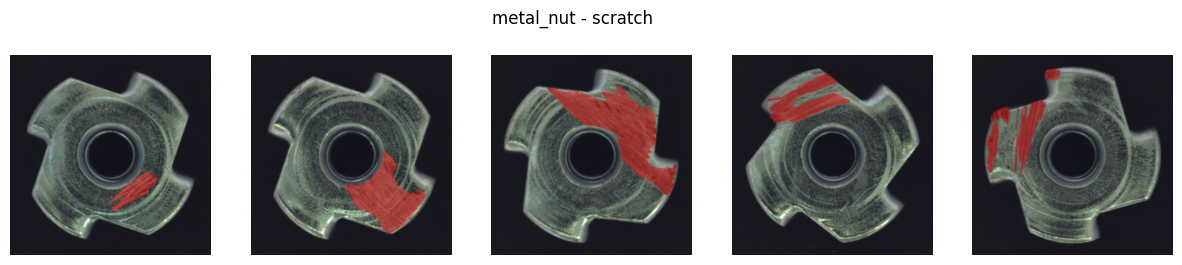

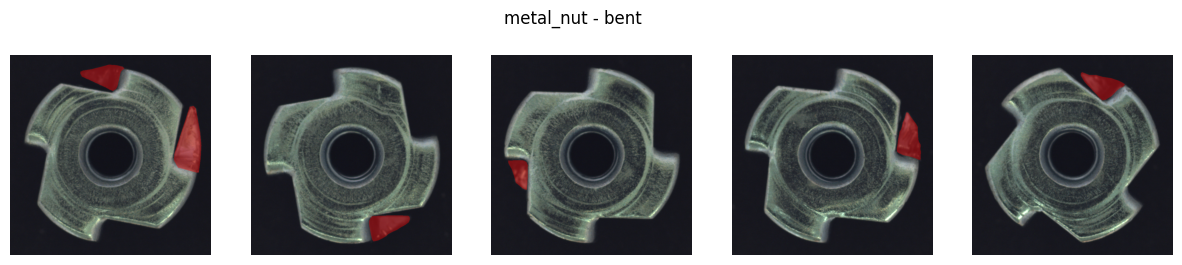

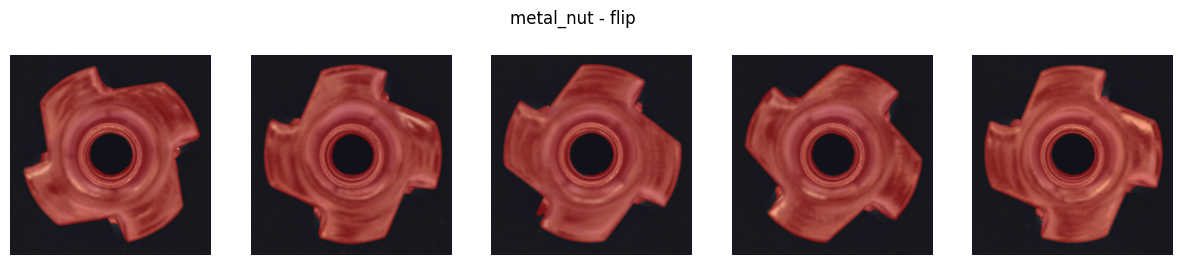

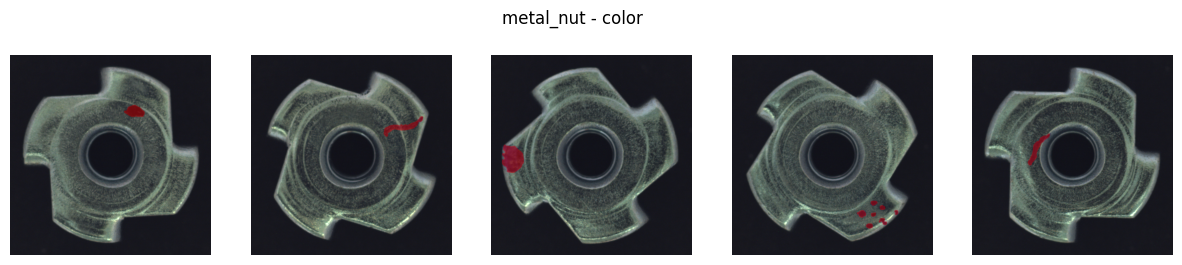

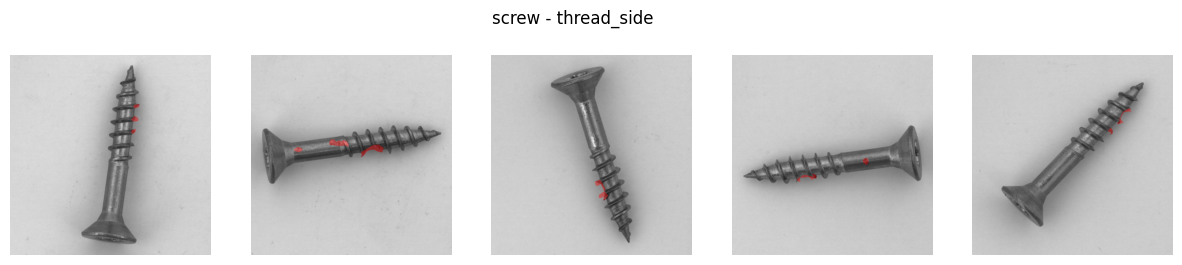

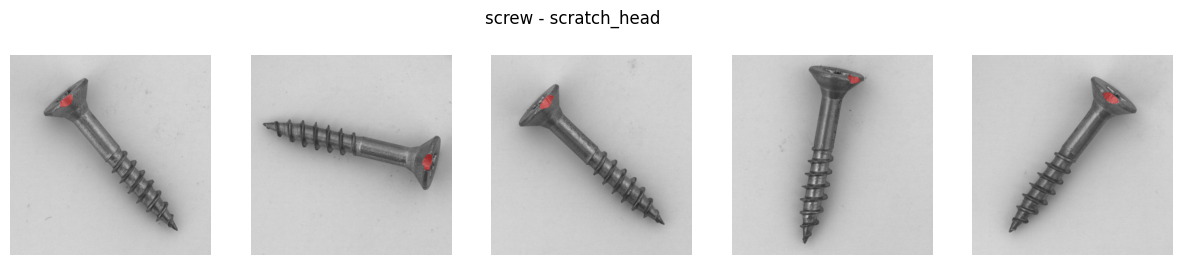

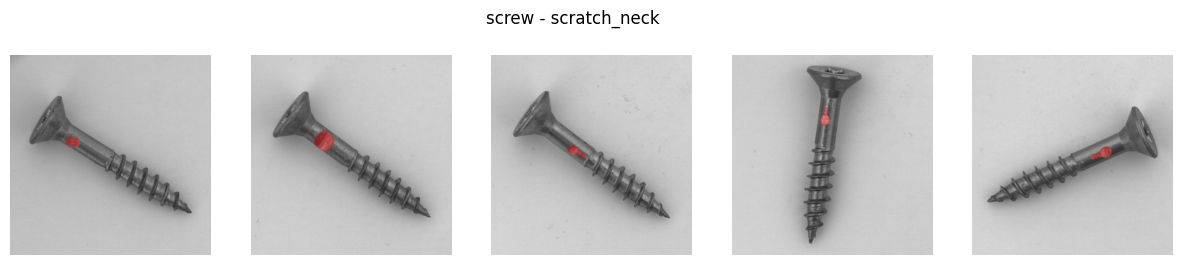

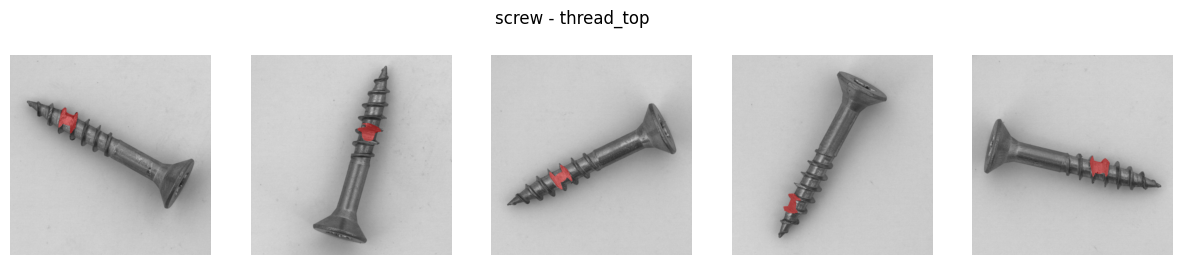

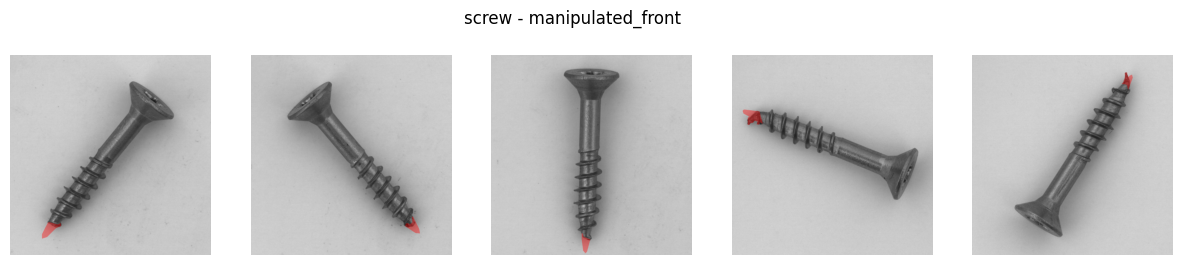

In [13]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

categories = ['metal_nut', 'screw']

for category in categories:
    test_root = f'/content/{category}/test'
    gt_root = f'/content/{category}/ground_truth'

    defect_types = [d for d in os.listdir(test_root) if d != 'good']

    for defect in defect_types:
        test_folder = os.path.join(test_root, defect)
        gt_folder = os.path.join(gt_root, defect)

        test_files = sorted(os.listdir(test_folder))[:5]

        fig, axes = plt.subplots(1, len(test_files), figsize=(15, 3))
        fig.suptitle(f'{category} - {defect}')

        for ax, fname in zip(axes, test_files):
            img = Image.open(os.path.join(test_folder, fname)).convert('RGB')

            # MVTec mask filenames usually match image name + _mask suffix
            mask_name = fname.replace('.png', '_mask.png')
            mask_path = os.path.join(gt_folder, mask_name)
            mask = Image.open(mask_path).convert('L')

            img_arr = np.array(img)
            mask_arr = np.array(mask)

            # red overlay wherever mask is defect
            overlay = img_arr.copy()
            overlay[mask_arr > 0] = [255, 0, 0]

            blended = (0.6 * img_arr + 0.4 * overlay).astype(np.uint8)

            ax.imshow(blended)
            ax.axis('off')

        plt.show()

In [14]:
! git config --global user.email "amirorman7@gmail.com"
! git config --global user.name "Amiroo00"

In [15]:
!git add .
!git commit -m "add eda script"
!git push

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address
